# Compressed Sensing MRI 

Python Starter Code for Prof. Miki Lustig's Compressive Sensing MRI assignment. https://people.eecs.berkeley.edu/~mlustig/CS.html 

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageNet
import matplotlib.pyplot as plt
import scipy.io
import pywt
from scipy.fft import fft, ifft, fft2, ifft2, fftshift, ifftshift
from IPython.display import clear_output
from inverse_solver import InverseSolver
import inverse_solver
import deepinv as dinv
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Helper Functions

These functions are provided for you. Run this cell before proceeding.

In [3]:
def fftc(x, axis=-1):
    """Centered 1D FFT with orthonormal scaling."""
    N = x.shape[axis]
    return fftshift(fft(ifftshift(x, axes=axis), axis=axis), axes=axis) / np.sqrt(N)


def ifftc(x, axis=-1):
    """Centered 1D inverse FFT with orthonormal scaling."""
    N = x.shape[axis]
    return fftshift(ifft(ifftshift(x, axes=axis), axis=axis), axes=axis) * np.sqrt(N)


def fft2c(x):
    """Centered 2D FFT with orthonormal scaling."""
    return fftshift(fft2(ifftshift(x))) / np.sqrt(x.size)


def ifft2c(x):
    """Centered 2D inverse FFT with orthonormal scaling."""
    return fftshift(ifft2(ifftshift(x))) * np.sqrt(x.size)


print("✓ Helper functions loaded!")

✓ Helper functions loaded!


Take the origional Model from this:
-Denoising: Soft thresholding
-Forward Model: Wavelet 
-Inverse Model: POCS

And make the following changes to compare:
-Denoising: Soft thresholding + Plug and Play Priors
-Forward Model: Wavelet
-Inverse Model: FISTA (Tv)

### PnP (Plug-and-Play Prior Setup)

In [4]:
model = dinv.models.DRUNet()
model.eval()


def PnPDenoiser(x, sigma=0.1):
    with torch.no_grad():
        x_input = torch.from_numpy(x)[None, None].to(device, dtype=torch.float32)
        x_denoised = model(x_input, sigma)
        return x_denoised.squeeze().cpu().numpy().clip(0, 1)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

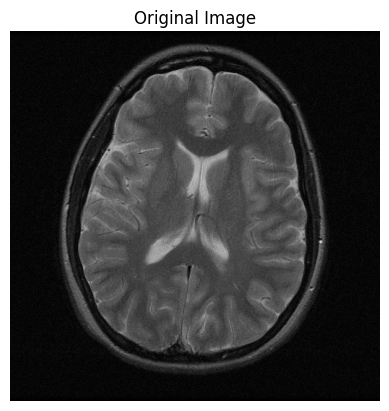

In [5]:
data = scipy.io.loadmat("brain.mat")

im = np.abs(data["im"] / np.max(data["im"]))
mask = data["mask_vardens"]
pdf = data["pdf_vardens"]

plt.imshow(np.abs(im), cmap="gray")
plt.title("Original Image")
plt.axis("off")

In [6]:
def A(x, mask):
    """Forward operator: FFT + Undersampling Mask"""
    # MRI samples in k-space (Fourier domain)
    kspace = fft2c(x)
    return kspace * mask


def A_adjoint(kspace_masked, mask):
    """Adjoint operator: Mask + IFFT"""
    # Back to image domain
    res = kspace_masked * mask
    return ifft2c(res)


def soft_thresh(z, threshold):
    """Soft-thresholding operator.

    Shrinks all values toward zero by `threshold`. Values with
    magnitude less than `threshold` become exactly zero:

        soft(z, t) = sign(z) * max(|z| - t, 0)

    Args:
        z: Input array
        threshold: Threshold value (>= 0)
    Returns:
        Soft-thresholded array (same shape as z)
    """
    return np.sign(z) * np.maximum(np.abs(z) - threshold, 0)


def prox_wavelet(x, lam):
    """Wavelet-domain soft thresholding."""
    coeffs = pywt.wavedec2(x, wavelet="db4", mode="periodization", level=4)
    # Apply thresholding to all coefficient levels
    coeffs_thresh = [coeffs[0]]  # Keep approximation coefficients
    for detail_level in coeffs[1:]:
        coeffs_thresh.append(tuple(soft_thresh(c, lam) for c in detail_level))
    return pywt.waverec2(coeffs_thresh, wavelet="db4", mode="periodization")

In [7]:
model = dinv.models.DRUNet(pretrained="download")
model.eval()


def PnPDenoiser(x, model, sigma=0.01):
    """DRUNet Denoising with channel padding to avoid RuntimeError"""
    x_real = np.real(x).astype(np.float32)
    with torch.no_grad():
        x_tensor = torch.from_numpy(x_real).unsqueeze(0).unsqueeze(0).to(device)
        x_padded = F.pad(x_tensor, (0, 0, 0, 0, 0, 2))
        s = torch.tensor([sigma]).to(device)
        denoised_padded = model(x_padded, s)
        return denoised_padded[0, 0, :, :].cpu().numpy()

In [60]:
def contractive_denoiser(x, model, sigma, alpha, L=0.9):
    """
    Enforces near-nonexpansiveness:
    - alpha: averaging strength (<= 1)
    - L: global Lipschitz shrink (< 1 for contraction)
    """
    Dx = PnPDenoiser(x, model, sigma)

    # residual contraction
    D_res = x + alpha * (Dx - x)
    # global Lipschitz clamp
    return L * D_res + (1 - L) * x


def estimate_lipschitz(mask, num_iter=30):
    """
    Estimate spectral norm of A*A via power iteration.
    A*A x = IFFT(mask * FFT(x))
    """
    # Random init
    x = np.random.randn(*mask.shape) + 1j * np.random.randn(*mask.shape)
    x /= np.linalg.norm(x)

    for _ in range(num_iter):
        # Apply A*A
        x_new = A_adjoint(A(x, mask), mask)  # your existing operators

        # Rayleigh quotient → eigenvalue estimate
        L = np.linalg.norm(x_new)
        x = x_new / L

    return L


def fista_reconstruct(
    y, mask, im_gt, model, iterations=100, alpha=0.2, gamma=0.1, sigma_pnp=0.01
):
    """
    y: K-space measurements
    mask: Sampling mask
    im_gt: Ground truth (for error tracking)
    model: Pre-trained DRUNet
    """
    x = np.zeros_like(im_gt)
    v = np.zeros_like(x)
    t = 1.0
    L = estimate_lipschitz(mask)
    step_size = 1.0 / L

    error_history = []

    for i in range(iterations):
        x_old = x.copy()

        grad = A_adjoint(A(v, mask) - y, mask)
        z = v - step_size * grad

        Dz = contractive_denoiser(z, model, sigma_pnp, alpha)
        x = z + gamma * (Dz - z)

        t_next = (1 + np.sqrt(1 + 4 * t**2)) / 2
        v = x + ((t - 1) / t_next) * (x - x_old)
        t = t_next

        rel_error = np.linalg.norm(np.abs(x) - im_gt) / np.linalg.norm(im_gt)
        error_history.append(rel_error)
        if (i + 1) % 10 == 0:
            print(f"Iteration {i+1}/{iterations} - Error: {rel_error:.6f}")
    return x, error_history

Final Image

In [61]:
y_measured = A(im, mask)

key1 = 0.5
key2 = 0.2
key3 = 0.001
reconstructed, error_log = fista_reconstruct(
    y_measured, mask, im, model, alpha=key1, gamma=key2, sigma_pnp=key3
)

Iteration 10/100 - Error: 0.080241
Iteration 20/100 - Error: 0.076966
Iteration 30/100 - Error: 0.076989
Iteration 40/100 - Error: 0.078113
Iteration 50/100 - Error: 0.080877
Iteration 60/100 - Error: 0.085960
Iteration 70/100 - Error: 0.094071
Iteration 80/100 - Error: 0.106101
Iteration 90/100 - Error: 0.123016
Iteration 100/100 - Error: 0.145778


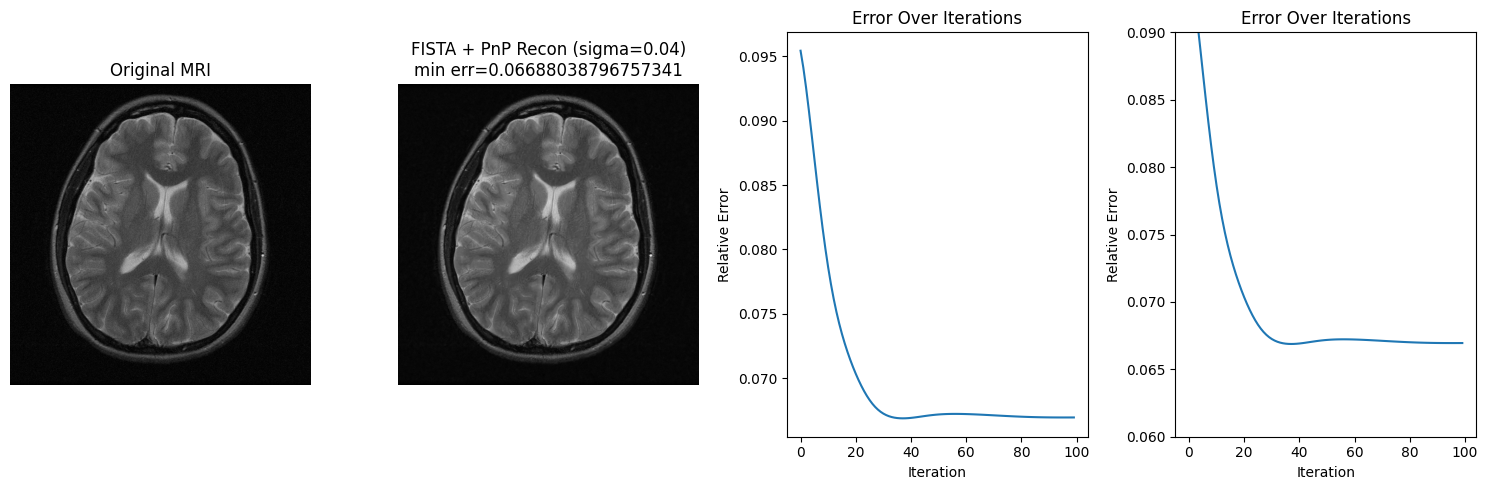

In [59]:
# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(np.abs(im), cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(reconstructed), cmap="gray")
plt.title(f"FISTA + PnP Recon (sigma={key3})\nmin err={np.min(error_log)}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.plot(error_log)
plt.title("Error Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Relative Error")

plt.subplot(1, 4, 4)
plt.plot(error_log)
plt.ylim([0.06, 0.09])
plt.title("Error Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Relative Error")

plt.tight_layout()
plt.show()